In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import sys
sys.path.append('..')
from config import *

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print("Libraries loaded!")
print(f"Data path: {RAW_DATA_PATH}")

Libraries loaded!
Data path: d:\Projects\healthcare-readmission-predictor\notebooks\..\data\raw\diabetic_data.csv


In [2]:
df = pd.read_csv(RAW_DATA_PATH, na_values='?')

print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"Shape            : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage     : {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")
print(f"Duplicate rows   : {df.duplicated().sum():,}")
print()
print("First 5 rows:")
df.head()

DATASET OVERVIEW
Shape            : 101,766 rows × 50 columns
Memory usage     : 225.90 MB
Duplicate rows   : 0

First 5 rows:


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
print("COLUMN DATA TYPES")
print("=" * 55)
print(f"Numerical columns   : {df.select_dtypes(include=np.number).shape[1]}")
print(f"Categorical columns : {df.select_dtypes(include='object').shape[1]}")
print()
print(df.dtypes.value_counts())
print()
print("\nColumn list:")
for i, (col, dtype) in enumerate(df.dtypes.items(), 1):
    print(f"  {i:2}. {col:<40} {str(dtype)}")

COLUMN DATA TYPES
Numerical columns   : 13
Categorical columns : 37

object    37
int64     13
Name: count, dtype: int64


Column list:
   1. encounter_id                             int64
   2. patient_nbr                              int64
   3. race                                     object
   4. gender                                   object
   5. age                                      object
   6. weight                                   object
   7. admission_type_id                        int64
   8. discharge_disposition_id                 int64
   9. admission_source_id                      int64
  10. time_in_hospital                         int64
  11. payer_code                               object
  12. medical_specialty                        object
  13. num_lab_procedures                       int64
  14. num_procedures                           int64
  15. num_medications                          int64
  16. number_outpatient                        int64
  17. numb

MISSING VALUES ANALYSIS
                   Missing Count  Missing %
weight                     98569      96.86
max_glu_serum              96420      94.75
A1Cresult                  84748      83.28
medical_specialty          49949      49.08
payer_code                 40256      39.56
race                        2273       2.23
diag_3                      1423       1.40
diag_2                       358       0.35
diag_1                        21       0.02

Total columns with missing : 9
Total missing values       : 374,017


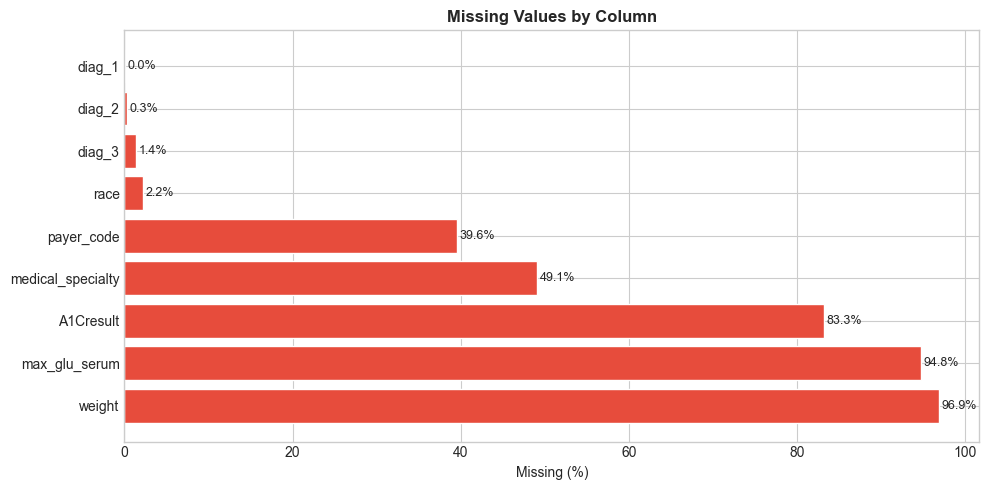

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values(
    'Missing %', ascending=False)

print("MISSING VALUES ANALYSIS")
print("=" * 45)
print(missing_df.to_string())
print()
print(f"Total columns with missing : {len(missing_df)}")
print(f"Total missing values       : {missing.sum():,}")

# Visualize
if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(missing_df.index,
                   missing_df['Missing %'],
                   color='#E74C3C', edgecolor='white')
    ax.set_xlabel('Missing (%)')
    ax.set_title('Missing Values by Column', fontweight='bold')
    for bar, val in zip(bars, missing_df['Missing %']):
        ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'missing_values.png',
                dpi=150, bbox_inches='tight')
    plt.show()

TARGET VARIABLE: readmitted
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

readmitted
NO     53.91
>30    34.93
<30    11.16
Name: proportion, dtype: float64


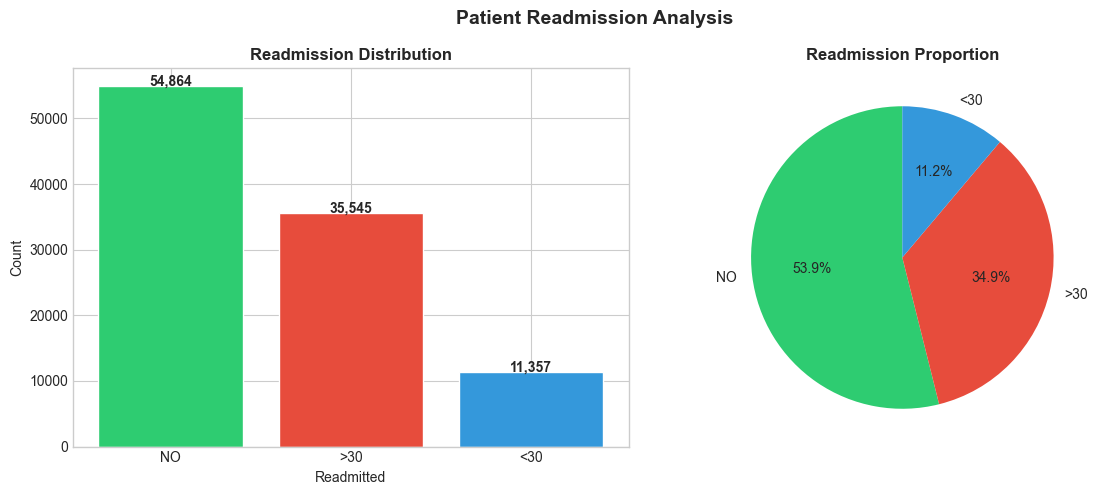

In [5]:
print("TARGET VARIABLE: readmitted")
print("=" * 45)
print(df['readmitted'].value_counts())
print()
print(df['readmitted'].value_counts(normalize=True).mul(100).round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
vc = df['readmitted'].value_counts()
colors = ['#2ECC71', '#E74C3C', '#3498DB']
axes[0].bar(vc.index, vc.values, color=colors, edgecolor='white')
axes[0].set_title('Readmission Distribution', fontweight='bold')
axes[0].set_xlabel('Readmitted')
axes[0].set_ylabel('Count')
for i, (label, val) in enumerate(vc.items()):
    axes[0].text(i, val + 100, f'{val:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(vc.values, labels=vc.index, colors=colors,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Readmission Proportion', fontweight='bold')

plt.suptitle('Patient Readmission Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'target_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

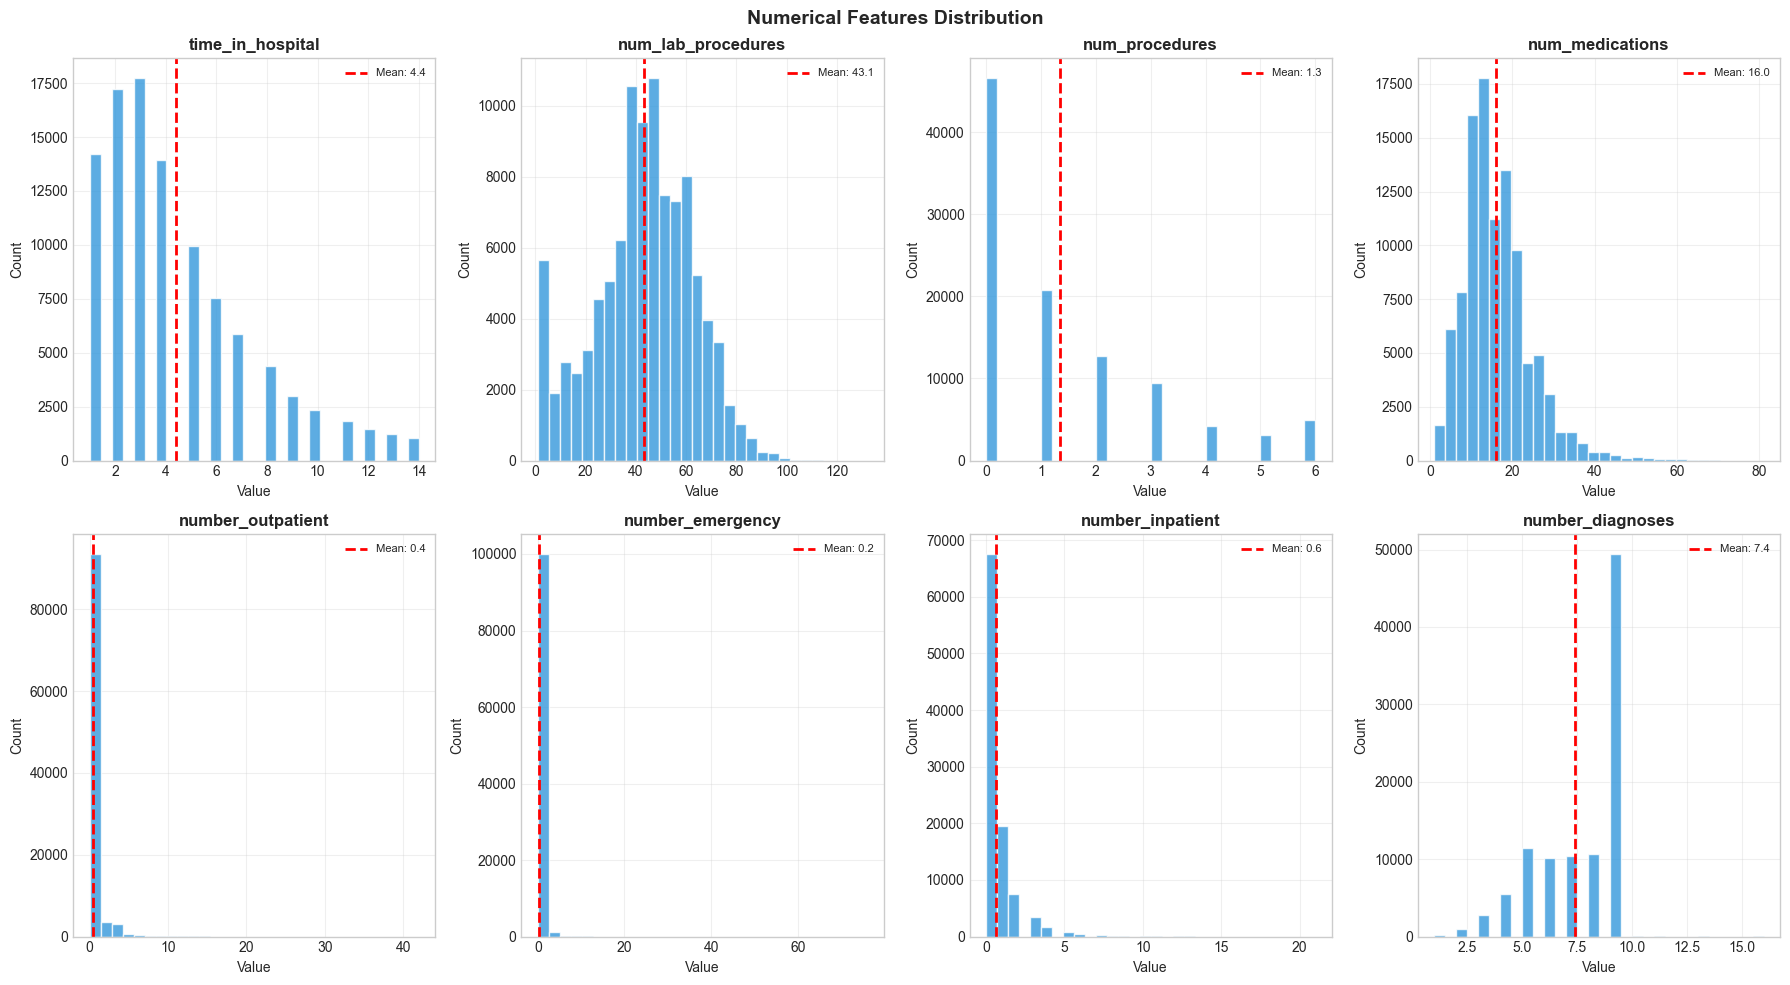

Statistical Summary:
       time_in_hospital  num_lab_procedures  num_procedures  num_medications  number_outpatient  number_emergency  number_inpatient  number_diagnoses
count         101766.00           101766.00       101766.00        101766.00          101766.00         101766.00         101766.00         101766.00
mean               4.40               43.10            1.34            16.02               0.37              0.20              0.64              7.42
std                2.99               19.67            1.71             8.13               1.27              0.93              1.26              1.93
min                1.00                1.00            0.00             1.00               0.00              0.00              0.00              1.00
25%                2.00               31.00            0.00            10.00               0.00              0.00              0.00              6.00
50%                4.00               44.00            1.00            15.00   

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.ravel()

for i, col in enumerate(NUMERICAL_COLS):
    axes[i].hist(df[col], bins=30,
                 color='#3498DB', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    
    mean_val = df[col].mean()
    axes[i].axvline(mean_val, color='red',
                    linestyle='--', linewidth=2,
                    label=f'Mean: {mean_val:.1f}')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Numerical Features Distribution',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'numerical_distributions.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Statistical Summary:")
print(df[NUMERICAL_COLS].describe().round(2).to_string())

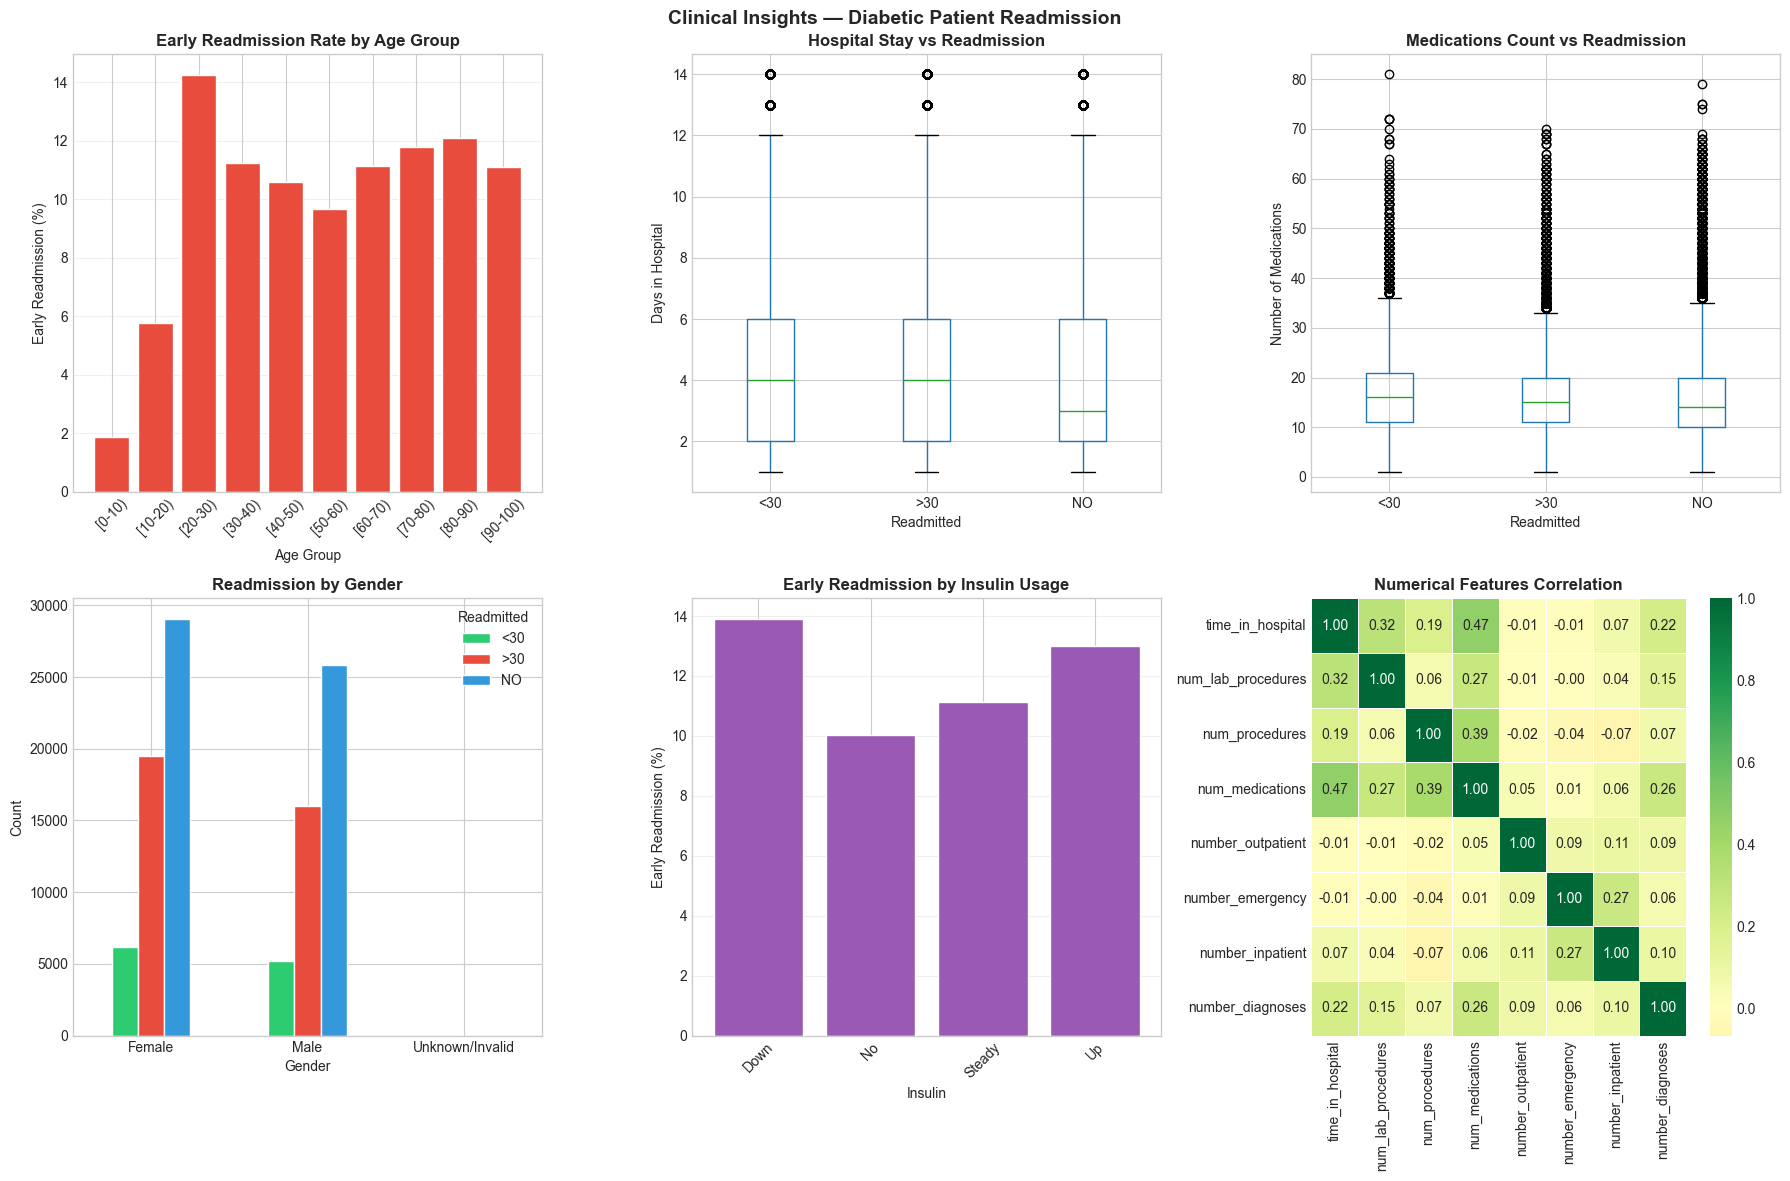

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Readmission by Age
age_readmit = df.groupby('age')['readmitted'].apply(
    lambda x: (x == '<30').mean() * 100).reset_index()
age_readmit.columns = ['age', 'early_readmit_pct']
axes[0,0].bar(age_readmit['age'],
              age_readmit['early_readmit_pct'],
              color='#E74C3C', edgecolor='white')
axes[0,0].set_title('Early Readmission Rate by Age Group',
                     fontweight='bold')
axes[0,0].set_xlabel('Age Group')
axes[0,0].set_ylabel('Early Readmission (%)')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].grid(True, alpha=0.3, axis='y')

# 2. Time in hospital by readmission
df.boxplot(column='time_in_hospital',
           by='readmitted', ax=axes[0,1])
axes[0,1].set_title('Hospital Stay vs Readmission',
                     fontweight='bold')
axes[0,1].set_xlabel('Readmitted')
axes[0,1].set_ylabel('Days in Hospital')

# 3. Medications by readmission
df.boxplot(column='num_medications',
           by='readmitted', ax=axes[0,2])
axes[0,2].set_title('Medications Count vs Readmission',
                     fontweight='bold')
axes[0,2].set_xlabel('Readmitted')
axes[0,2].set_ylabel('Number of Medications')

# 4. Gender distribution
gender_readmit = df.groupby(['gender', 'readmitted']).size().unstack()
gender_readmit.plot(kind='bar', ax=axes[1,0],
                    color=['#2ECC71','#E74C3C','#3498DB'],
                    edgecolor='white')
axes[1,0].set_title('Readmission by Gender',
                     fontweight='bold')
axes[1,0].set_xlabel('Gender')
axes[1,0].set_ylabel('Count')
axes[1,0].tick_params(axis='x', rotation=0)
axes[1,0].legend(title='Readmitted')

# 5. Insulin usage
insulin_readmit = df.groupby('insulin')['readmitted'].apply(
    lambda x: (x == '<30').mean() * 100)
axes[1,1].bar(insulin_readmit.index,
              insulin_readmit.values,
              color='#9B59B6', edgecolor='white')
axes[1,1].set_title('Early Readmission by Insulin Usage',
                     fontweight='bold')
axes[1,1].set_xlabel('Insulin')
axes[1,1].set_ylabel('Early Readmission (%)')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].grid(True, alpha=0.3, axis='y')

# 6. Correlation heatmap
corr = df[NUMERICAL_COLS].corr()
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0,
            ax=axes[1,2], linewidths=0.5)
axes[1,2].set_title('Numerical Features Correlation',
                     fontweight='bold')

plt.suptitle('Clinical Insights — Diabetic Patient Readmission',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'clinical_insights.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [8]:
print("=" * 58)
print("EDA SUMMARY — DIABETIC PATIENT READMISSION")
print("=" * 58)
print(f"Total patients      : {len(df):,}")
print(f"Total features      : {df.shape[1]}")
print(f"Numerical features  : {len(NUMERICAL_COLS)}")
print(f"Categorical features: {len(CATEGORICAL_COLS)}")
print()
print("Target Distribution:")
for label, count in df['readmitted'].value_counts().items():
    pct = count / len(df) * 100
    print(f"  {label:<8} : {count:>6,} ({pct:.1f}%)")
print()
print("Key Clinical Findings:")
print("  - Early readmission (<30 days) more common in")
print("    older age groups")
print("  - Longer hospital stay correlates with")
print("    higher readmission")
print("  - More medications = higher readmission risk")
print("  - Insulin usage significantly impacts")
print("    readmission rates")
print()
print("Missing Values:")
for col, pct in missing_pct[missing_pct > 0].items():
    print(f"  {col:<35} : {pct:.1f}%")
print()
print("Next Step: 02_preprocessing.ipynb")
print("=" * 58)

EDA SUMMARY — DIABETIC PATIENT READMISSION
Total patients      : 101,766
Total features      : 50
Numerical features  : 8
Categorical features: 37

Target Distribution:
  NO       : 54,864 (53.9%)
  >30      : 35,545 (34.9%)
  <30      : 11,357 (11.2%)

Key Clinical Findings:
  - Early readmission (<30 days) more common in
    older age groups
  - Longer hospital stay correlates with
    higher readmission
  - More medications = higher readmission risk
  - Insulin usage significantly impacts
    readmission rates

Missing Values:
  race                                : 2.2%
  weight                              : 96.9%
  payer_code                          : 39.6%
  medical_specialty                   : 49.1%
  diag_1                              : 0.0%
  diag_2                              : 0.3%
  diag_3                              : 1.4%
  max_glu_serum                       : 94.8%
  A1Cresult                           : 83.3%

Next Step: 02_preprocessing.ipynb
